<a href="https://colab.research.google.com/github/Akanshajoshiiii/NLP_LAB/blob/main/1_SkipGram_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import requests
import zipfile
import io
from collections import Counter
from torch.utils.data import DataLoader,Dataset
import re
import pandas as pd

link= cleaned version of wikipedia text , all lowercase and punctuations removed  




In [ ]:
url = "http://mattmahoney.net/dc/text8.zip"
r = requests.get(url) #http get request to download the file
z = zipfile.ZipFile(io.BytesIO(r.content))
text = z.read("text8").decode("utf-8")
tokens = text.split() #divides text into words using spaces
print("Total tokens:", len(tokens))

Total tokens: 17005207


tokens = ["deep","learning","is","deep","learning","fun"]  
Counter output:

{
 "deep":2,
 "learning":2,
 "is":1,
 "fun":1
}  


***vocab[word]=len(vocab)***  

word = "the"
vocab = {}
len(vocab) = 0

Result:

vocab = {"the":0}
iteration 2
word = "of"
len(vocab) = 1

In [ ]:
min_freq=5 #keep words that appear atleat 5 times in the dataset, remove rare words
counter=Counter(tokens) #counts occourances of each word
vocab={} #dictionary , word->unique index
for word,freq in counter.items(): #(word,freq)
    if freq>=min_freq: #if freq less than min , dont keep
        vocab[word]=len(vocab) #gives nxt available index
print(len(vocab))


71290


vocab = {
 "the":0,
 "king":1,
 "queen":2,
 "man":3
}  
word2index= simply creates maping again  
(word,index)

In [ ]:
word2index={word:index for word,index in vocab.items()}
index2word={index:word for word,index in vocab.items()} #index to word

***indexed=[vocab[word] for word in tokens if word in vocab]***

indexed = []

for word in tokens:  
    if word in vocab:  
        indexed.append(vocab[word])

In [ ]:
pairs=[] #This will store SkipGram training pairs. (center_word_index, context_word_index)
windows_size=2
indexed=[vocab[word] for word in tokens if word in vocab] #convert to indices

*if (j!=0 and 0<=i+j<len(indexed)):*   
 if j=0 ->center word predicting itself  , (deep , deep)Ye useless hai → skip.    
 **0 <= i+j < len(indexed)**    
 0 <= i+j  AND  i+j < len(indexed)  
 window_size = 1

To j values hongi:

-1, 0, 1

Ab i+j calculate karte hain.  
Case 1
j = -1
i + j = 0 + (-1) = -1

Check:

0 <= -1 < 4

❌ False

Kyuki -1 valid index nahi hai.   


In [ ]:
for i,center_word in enumerate(indexed): # enumerate gives index,value
    for j in range(-windows_size,windows_size+1): #range_wind t-1,t,t+1
        if (j!=0 and 0<=i+j<len(indexed)):# j!=0 ,
            contextual_word=indexed[i+j]
            pairs.append((center_word,contextual_word))

In [ ]:
len(pairs)

66875370

self.pairs = [(2,3), (1,4), (3,2)]

Agar:

index = 0

To:

self.pairs[0] = (2,3)

Isliye:

central = 2
contextual = 3

Meaning:

center word index = 2
context word index = 3

In [ ]:
import torch.nn.functional as F
class SkipgramDataset(Dataset):
    def __init__(self,pairs,vocab_size): #initialise dataset
        self.pairs=pairs
        self.vocab_size=vocab_size
    def __len__(self):
        return len(self.pairs)  #no of pairs/dataset length
    def __getitem__(self,index): #dataset ka nth sample
        central,contextual=self.pairs[index] #us sample ka cent,cntxt
        central_one_hot=F.one_hot(torch.tensor(central),num_classes=self.vocab_size).float()
        return central_one_hot,torch.tensor(contextual)
        # returns (input , target)

Suppose:

**central = 2**  
*vocab_size = 5 *

To one-hot vector banega:

[0,0,1,0,0]

Visualization:

index:   0 1 2 3 4  
vector:  0 0 1 0 0

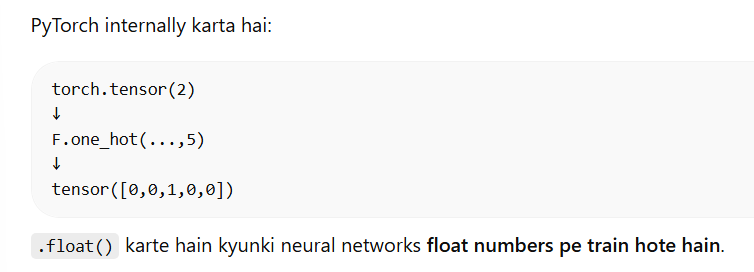

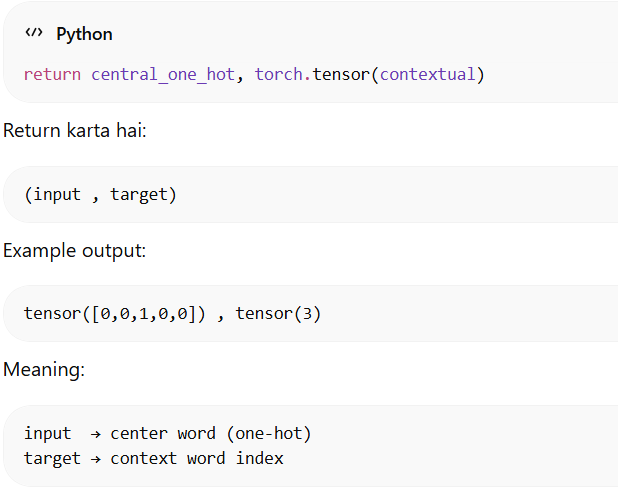
          

In [ ]:
data=SkipgramDataset(pairs,len(vocab))

In [ ]:
class skipgram_model(nn.Module):
    def __init__(self,vocab_size,output_dim):
        super(skipgram_model,self).__init__()
        self.hidden_layer=nn.Linear(vocab_size,output_dim,bias=False)
        self.output_layer=nn.Linear(output_dim,vocab_size,bias=False)
    def forward(self,input):
        x=self.hidden_layer(input)
        output=self.output_layer(x)
        return output


Input = one-hot vector of center word  
Hidden layer → embedding vector  
Output layer → scores (logits) for all words

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
model=skipgram_model(len(vocab),100).to(device)

In [ ]:
optimizer=torch.optim.Adam(model.parameters())
loss_fn=nn.CrossEntropyLoss()

In [ ]:
loader=DataLoader(data,batch_size=1024,shuffle=True,num_workers=2)

📊 What is tqdm?

tqdm is a Python library that shows a progress bar for loops.

👉 It helps you see training progress in real time instead of waiting blindly.

In [ ]:
epochs=10
from tqdm import tqdm
for i  in range(epochs):
    loss=0
    model.train()
    loop = tqdm(loader, desc=f"Epoch {i+1}/{epochs}", leave=False)
    for (x_batch,y_batch) in loop:
        optimizer.zero_grad()
        x_batch,y_batch=x_batch.to(device),y_batch.to(device)
        y_pred=model(x_batch)
        batch_loss=loss_fn(y_pred,y_batch)
        batch_loss.backward()
        optimizer.step()
        loss+=batch_loss.item()
         #Update tqdm live loss
        loop.set_postfix(loss=batch_loss.item())
    print(f'Training Loss over epoch {i+1} is {loss/len(loader)}')



Epoch 1/10:   1%|▏         | 850/65308 [01:50<2:03:00,  8.73it/s, loss=7.48]